# Feature Engineering for Unsupervised Learning (Clustering)

This notebook prepares features specifically for clustering models (KMeans, DBSCAN).
Unlike supervised learning, we focus on feature intrinsic properties without target labels.

**Key Differences from Supervised Feature Engineering:**
- ❌ No target-based feature selection (no ANOVA, Mutual Information with target)
- ❌ No Random Forest importance (requires labels)
- ✅ Variance-based feature selection (high-variance features capture more information)
- ✅ Multicollinearity removal based on correlation threshold only (no target involved)
- ✅ Distance metric analysis (features that separate clusters better)
- ✅ Silhouette analysis (evaluate clustering quality with different features)
- ✅ Feature scaling is CRITICAL for distance-based clustering

In [1]:
# Add project root to path and import config
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))
from config import (
    FIRES_MERGED_UNSUPERVISED, 
    FIRES_ENGINEERED_UNSUPERVISED, 
    FIRES_ENGINEERED_PCA_UNSUPERVISED
)

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Config and libraries imported for UNSUPERVISED learning")
print(f"   Input: {FIRES_MERGED_UNSUPERVISED}")
print(f"   Output (no PCA): {FIRES_ENGINEERED_UNSUPERVISED}")
print(f"   Output (with PCA): {FIRES_ENGINEERED_PCA_UNSUPERVISED}")

✅ Config and libraries imported for UNSUPERVISED learning
   Input: C:\Users\Azur\Downloads\TP\DM\results\intermediate\unsupervised\fires_merged_all_features.csv
   Output (no PCA): C:\Users\Azur\Downloads\TP\DM\results\features\unsupervised\fires_engineered_features.csv
   Output (with PCA): C:\Users\Azur\Downloads\TP\DM\results\features\unsupervised\fires_engineered_pca.csv


In [2]:
# Load the merged dataset for unsupervised learning
df = pd.read_csv(FIRES_MERGED_UNSUPERVISED)

print(f"Dataset shape: {df.shape}")
print(f"\nDataset columns ({len(df.columns)}):")
print(df.columns.tolist())

# Check if TEXTURE_SOTER was already one-hot encoded in soil.ipynb
texture_soter_cols = [col for col in df.columns if col.startswith('TEXTURE_SOTER')]
if texture_soter_cols:
    print(f"\n✅ TEXTURE_SOTER encoding detected:")
    for col in texture_soter_cols:
        if col == 'TEXTURE_SOTER':
            print(f"  - {col}: categorical (should be encoded in soil.ipynb)")
        else:
            print(f"  - {col}: binary encoded")
else:
    print("\n⚠ No TEXTURE_SOTER columns found")

print(f"\n📊 Dataset Preview:")
print(df.head())

Dataset shape: (28432, 44)

Dataset columns (44):
['longitude', 'latitude', 'class', 'prec_winter', 'tmax_winter', 'tmin_winter', 'prec_spring', 'tmax_spring', 'tmin_spring', 'prec_summer', 'tmax_summer', 'tmin_summer', 'prec_autumn', 'tmax_autumn', 'tmin_autumn', 'elevation', 'slope', 'aspect', 'roughness', 'soil_unit_id', 'COARSE', 'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA', 'BULK', 'REF_BULK', 'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND', 'TEXTURE_SOTER_F', 'TEXTURE_SOTER_M', 'TEXTURE_SOTER_V']

✅ TEXTURE_SOTER encoding detected:
  - TEXTURE_SOTER_F: binary encoded
  - TEXTURE_SOTER_M: binary encoded
  - TEXTURE_SOTER_V: binary encoded

📊 Dataset Preview:
   longitude  latitude  class  prec_winter  tmax_winter  tmin_winter  \
0    6.79057  31.18797      1     0.567779     0.157885     0.150544   
1   -0.43306  25.84771      0    -1.646185     1.325763     2.210610   
2    5.10321

## 2. Feature Extraction

Create new features from existing ones to capture domain knowledge and improve predictive power.

### 2.1 Climate-Based Features

In [3]:
# Create a copy for feature engineering
df_engineered = df.copy()

# Temperature features
# Annual temperature range (max - min across all seasons)
temp_max_cols = ['tmax_winter', 'tmax_spring', 'tmax_summer', 'tmax_autumn']
temp_min_cols = ['tmin_winter', 'tmin_spring', 'tmin_summer', 'tmin_autumn']

df_engineered['annual_temp_range'] = df_engineered[temp_max_cols].max(axis=1) - df_engineered[temp_min_cols].min(axis=1)
df_engineered['avg_tmax'] = df_engineered[temp_max_cols].mean(axis=1)
df_engineered['avg_tmin'] = df_engineered[temp_min_cols].mean(axis=1)
df_engineered['diurnal_temp_range'] = df_engineered['avg_tmax'] - df_engineered['avg_tmin']

# Precipitation features
prec_cols = ['prec_winter', 'prec_spring', 'prec_summer', 'prec_autumn']
df_engineered['total_annual_precip'] = df_engineered[prec_cols].sum(axis=1)
df_engineered['summer_precip_ratio'] = df_engineered['prec_summer'] / (df_engineered['total_annual_precip'] + 1e-6)
df_engineered['precip_variability'] = df_engineered[prec_cols].std(axis=1)

# Fire season indicators (summer is typically high fire risk)
df_engineered['summer_heat_index'] = df_engineered['tmax_summer'] - df_engineered['prec_summer']
df_engineered['drought_index'] = df_engineered['tmax_summer'] / (df_engineered['prec_summer'] + 1)

print(f"Created {9} climate-based features")
print(f"New shape: {df_engineered.shape}")

Created 9 climate-based features
New shape: (28432, 53)


### 2.2 Topography-Based Features

In [4]:
# Terrain ruggedness and fire accessibility
df_engineered['terrain_complexity'] = df_engineered['slope'] * df_engineered['roughness']
df_engineered['elevation_slope_interaction'] = df_engineered['elevation'] * df_engineered['slope']

# Aspect categories (convert continuous aspect to cardinal directions)
# North: 0°-45°, 315°-360° (coded as 0)
# East: 45°-135° (coded as 1)
# South: 135°-225° (coded as 2)
# West: 225°-315° (coded as 3)
def aspect_to_cardinal(aspect):
    if -1 <= aspect <= 1:  # Normalized aspect values
        # Convert normalized aspect back to degrees (assuming -1 to 1 maps to 0 to 360)
        aspect_deg = (aspect + 1) * 180
        if (aspect_deg >= 0 and aspect_deg < 45) or (aspect_deg >= 315 and aspect_deg <= 360):
            return 0  # North
        elif aspect_deg >= 45 and aspect_deg < 135:
            return 1  # East
        elif aspect_deg >= 135 and aspect_deg < 225:
            return 2  # South
        else:
            return 3  # West
    return 0

df_engineered['aspect_cardinal'] = df_engineered['aspect'].apply(aspect_to_cardinal)

# South-facing slopes receive more solar radiation (higher fire risk)
df_engineered['is_south_facing'] = (df_engineered['aspect_cardinal'] == 2).astype(int)

print(f"Created {4} topography-based features")
print(f"New shape: {df_engineered.shape}")

Created 4 topography-based features
New shape: (28432, 57)


### 2.3 Soil-Based Features

In [5]:
# Soil composition ratios
df_engineered['sand_clay_ratio'] = df_engineered['SAND'] / (df_engineered['CLAY'] + 1e-6)
df_engineered['fine_fraction'] = df_engineered['SILT'] + df_engineered['CLAY']

# Soil fertility and moisture indicators
df_engineered['fertility_index'] = df_engineered['ORG_CARBON'] * df_engineered['TOTAL_N']
df_engineered['moisture_retention'] = df_engineered['CLAY'] * df_engineered['ORG_CARBON']

# Chemical properties
df_engineered['ph_carbon_interaction'] = df_engineered['PH_WATER'] * df_engineered['ORG_CARBON']
df_engineered['nutrient_availability'] = df_engineered['CEC_SOIL'] * df_engineered['BSAT']

print(f"Created {6} soil-based features")
print(f"New shape: {df_engineered.shape}")

Created 6 soil-based features
New shape: (28432, 63)


### 2.4 Spatial Features

In [6]:
# Geographic regions (Algeria vs Tunisia based on longitude)
# Algeria: longitude < 10, Tunisia: longitude >= 10 (approximately)
df_engineered['country'] = (df_engineered['longitude'] >= 10).astype(int)  # 0: Algeria, 1: Tunisia

# Distance from coast (using latitude as proxy - lower latitude = closer to coast)
df_engineered['coastal_proximity'] = 37 - df_engineered['latitude']  # Max latitude is ~37

# Coordinate clustering (spatial density)
df_engineered['lat_long_interaction'] = df_engineered['latitude'] * df_engineered['longitude']

print(f"Created {3} spatial features")
print(f"New shape: {df_engineered.shape}")

Created 3 spatial features
New shape: (28432, 66)


In [7]:
# Summary of feature extraction
original_features = df.shape[1]
new_features = df_engineered.shape[1] - original_features

print(f"\n{'='*60}")
print(f"Feature Extraction Summary")
print(f"{'='*60}")
print(f"Original features: {original_features}")
print(f"New features created: {new_features}")
print(f"Total features: {df_engineered.shape[1]}")
print(f"\nNew features:")
new_feature_names = df_engineered.columns[original_features:].tolist()
for i, feat in enumerate(new_feature_names, 1):
    print(f"  {i}. {feat}")


Feature Extraction Summary
Original features: 44
New features created: 22
Total features: 66

New features:
  1. annual_temp_range
  2. avg_tmax
  3. avg_tmin
  4. diurnal_temp_range
  5. total_annual_precip
  6. summer_precip_ratio
  7. precip_variability
  8. summer_heat_index
  9. drought_index
  10. terrain_complexity
  11. elevation_slope_interaction
  12. aspect_cardinal
  13. is_south_facing
  14. sand_clay_ratio
  15. fine_fraction
  16. fertility_index
  17. moisture_retention
  18. ph_carbon_interaction
  19. nutrient_availability
  20. country
  21. coastal_proximity
  22. lat_long_interaction


## 3. Feature Selection (Unsupervised Methods)

For clustering, we use unsupervised methods that don't depend on target labels.
Focus on feature variance, correlations, and their impact on cluster quality.

### 3.1 Prepare Data and Check Feature Properties

In [8]:
# Remove non-feature columns (keep longitude, latitude for spatial analysis)
X = df_engineered.drop(['class', 'longitude', 'latitude'], axis=1)
# Note: For unsupervised clustering, we DON'T use 'class' in feature selection
# But we'll keep it for later evaluation and visualization

print("="*80)
print("UNSUPERVISED FEATURE ENGINEERING")
print("="*80)

print(f"\n📊 Feature Properties Before Selection:")
print(f"  Total features: {X.shape[1]}")
print(f"  Total samples: {X.shape[0]}")

# Check if TEXTURE_SOTER has been one-hot encoded (done in soil.ipynb)
one_hot_cols = [col for col in X.columns if col.startswith('TEXTURE_SOTER_')]
if one_hot_cols:
    print(f"\n✅ TEXTURE_SOTER already one-hot encoded (from soil.ipynb):")
    for col in one_hot_cols:
        ones_count = X[col].sum()
        print(f"   - {col}: {int(ones_count)} instances (1), {len(X) - int(ones_count)} instances (0)")
else:
    print(f"\n⚠ No TEXTURE_SOTER one-hot columns found")

print(f"\n{'='*80}")
print(f"FEATURE SET READY FOR UNSUPERVISED SELECTION")
print(f"{'='*80}")
print(f"Total features: {X.shape[1]}")
print(f"All features are numerical")

UNSUPERVISED FEATURE ENGINEERING

📊 Feature Properties Before Selection:
  Total features: 63
  Total samples: 28432

✅ TEXTURE_SOTER already one-hot encoded (from soil.ipynb):
   - TEXTURE_SOTER_F: 411 instances (1), 28021 instances (0)
   - TEXTURE_SOTER_M: 25081 instances (1), 3351 instances (0)
   - TEXTURE_SOTER_V: 0 instances (1), 28432 instances (0)

FEATURE SET READY FOR UNSUPERVISED SELECTION
Total features: 63
All features are numerical


In [9]:
print("="*80)
print("STEP 1: REMOVE MULTICOLLINEARITY (WITHOUT TARGET)")
print("="*80)

# Create numerical_X from all features
numerical_X = X.copy()

# Calculate correlation matrix for numerical features
correlation_matrix = numerical_X.corr().abs()

print(f"\nTotal numerical features: {X.shape[1]}")
print(f"Analyzing feature-to-feature correlations (NO target involved)...\n")

# Find pairs of highly correlated features
threshold_multicollinearity = 0.90
to_remove = set()
pairs_found = []

# Iterate through correlation matrix (upper triangle only)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        feat_i = correlation_matrix.columns[i]
        feat_j = correlation_matrix.columns[j]
        
        # If features are highly correlated
        if correlation_matrix.iloc[i, j] > threshold_multicollinearity:
            corr_value = correlation_matrix.iloc[i, j]
            
            # For unsupervised: keep the feature with HIGHER VARIANCE (more information)
            var_i = numerical_X[feat_i].var()
            var_j = numerical_X[feat_j].var()
            
            if var_i >= var_j:
                to_remove.add(feat_j)
                kept_feature = feat_i
                removed_feature = feat_j
                kept_var = var_i
                removed_var = var_j
            else:
                to_remove.add(feat_i)
                kept_feature = feat_j
                removed_feature = feat_i
                kept_var = var_j
                removed_var = var_i
            
            pairs_found.append({
                'feature_1': feat_i,
                'feature_2': feat_j,
                'pair_correlation': corr_value,
                'kept': kept_feature,
                'removed': removed_feature,
                'kept_variance': kept_var,
                'removed_variance': removed_var
            })

# Display pairs information
if pairs_found:
    print(f"Found {len(pairs_found)} highly correlated pairs (correlation > {threshold_multicollinearity}):\n")
    for idx, pair in enumerate(pairs_found, 1):
        print(f"  Pair {idx}: '{pair['feature_1']}' ↔ '{pair['feature_2']}'")
        print(f"    Feature-to-Feature correlation: {pair['pair_correlation']:.3f}")
        print(f"    ✓ Kept '{pair['kept']}' (variance: {pair['kept_variance']:.4f})")
        print(f"    ✗ Removed '{pair['removed']}' (variance: {pair['removed_variance']:.4f})")
        print()
else:
    print(f"No highly correlated pairs found (threshold: {threshold_multicollinearity})")

print(f"{'='*80}")
print(f"✅ Multicollinearity Removal Complete (UNSUPERVISED)")
print(f"{'='*80}")
print(f"Features to remove: {len(to_remove)}")
print(f"Features remaining: {X.shape[1] - len(to_remove)}")

# Remove redundant features
numerical_X_reduced = numerical_X.drop(columns=list(to_remove))
print(f"\nReduced feature set shape: {numerical_X_reduced.shape}")

STEP 1: REMOVE MULTICOLLINEARITY (WITHOUT TARGET)

Total numerical features: 63
Analyzing feature-to-feature correlations (NO target involved)...

Found 15 highly correlated pairs (correlation > 0.9):

  Pair 1: 'tmax_autumn' ↔ 'avg_tmax'
    Feature-to-Feature correlation: 0.945
    ✓ Kept 'tmax_autumn' (variance: 0.9999)
    ✗ Removed 'avg_tmax' (variance: 0.7409)

  Pair 2: 'tmin_autumn' ↔ 'avg_tmin'
    Feature-to-Feature correlation: 0.943
    ✓ Kept 'tmin_autumn' (variance: 0.9999)
    ✗ Removed 'avg_tmin' (variance: 0.7052)

  Pair 3: 'SAND' ↔ 'REF_BULK'
    Feature-to-Feature correlation: 0.910
    ✓ Kept 'SAND' (variance: 0.4953)
    ✗ Removed 'REF_BULK' (variance: 0.3813)

  Pair 4: 'SILT' ↔ 'fine_fraction'
    Feature-to-Feature correlation: 0.908
    ✓ Kept 'fine_fraction' (variance: 1.1611)
    ✗ Removed 'SILT' (variance: 0.3116)

  Pair 5: 'CLAY' ↔ 'TEXTURE_USDA'
    Feature-to-Feature correlation: 0.904
    ✓ Kept 'TEXTURE_USDA' (variance: 0.4519)
    ✗ Removed 'CLAY' (v

In [10]:
print("="*80)
print("STEP 2: VARIANCE-BASED FEATURE SELECTION")
print("="*80)

# For unsupervised learning, keep features with high variance
# High variance = feature captures more information

feature_variance = numerical_X_reduced.var().sort_values(ascending=False)

print(f"\nFeatures after multicollinearity removal: {len(feature_variance)}")
print(f"\nFeature variance ranking (top 20):\n")

for i, (feat, var) in enumerate(feature_variance.head(20).items(), 1):
    print(f"  {i:2d}. {feat:45s} | variance = {var:10.4f}")

# Calculate variance percentile (cumulative)
print(f"\n📊 Variance Distribution:")
total_var = feature_variance.sum()
cumsum_var = feature_variance.cumsum()
cumsum_pct = (cumsum_var / total_var * 100)
print(f"  Total variance: {total_var:.4f}")
print(f"  Top 5 features explain {cumsum_pct.iloc[4]:.1f}% of total variance")
print(f"  Top 10 features explain {cumsum_pct.iloc[9]:.1f}% of total variance")

# For unsupervised: we'll use all features after multicollinearity removal
# But analyze which subsets work best via silhouette scores
numerical_X_selected = numerical_X_reduced.copy()

print(f"\n{'='*80}")
print(f"✅ Variance Analysis Complete")
print(f"{'='*80}")
print(f"Selected all features after multicollinearity removal: {len(numerical_X_selected.columns)}")
print(f"These will be evaluated for clustering quality in next steps")

STEP 2: VARIANCE-BASED FEATURE SELECTION

Features after multicollinearity removal: 53

Feature variance ranking (top 20):

   1. soil_unit_id                                  | variance = 60867672.3381
   2. lat_long_interaction                          | variance = 15561.2275
   3. summer_precip_ratio                           | variance =   411.7460
   4. coastal_proximity                             | variance =    16.2517
   5. sand_clay_ratio                               | variance =    13.7829
   6. total_annual_precip                           | variance =     8.1985
   7. summer_heat_index                             | variance =     2.8744
   8. drought_index                                 | variance =     2.8668
   9. TCARBON_EQ                                    | variance =     2.5046
  10. CEC_CLAY                                      | variance =     2.4241
  11. terrain_complexity                            | variance =     1.8285
  12. elevation_slope_interaction    

### 3.2 Silhouette Analysis - Evaluate Feature Subsets

Evaluate how different feature subsets affect clustering quality using Silhouette Score.
This is an unsupervised metric that measures cluster cohesion and separation.

SILHOUETTE ANALYSIS: Evaluate Feature Subsets for Clustering

Evaluating KMeans clustering quality with different feature counts...

  Features:  5 | Silhouette:  0.3884 | Davies-Bouldin:  1.0117
  Features: 10 | Silhouette:  0.3268 | Davies-Bouldin:  1.3998
  Features: 15 | Silhouette:  0.2702 | Davies-Bouldin:  1.7151
  Features: 20 | Silhouette:  0.2234 | Davies-Bouldin:  1.6862
  Features: 53 | Silhouette:  0.1974 | Davies-Bouldin:  1.8497

✅ Silhouette Analysis Complete


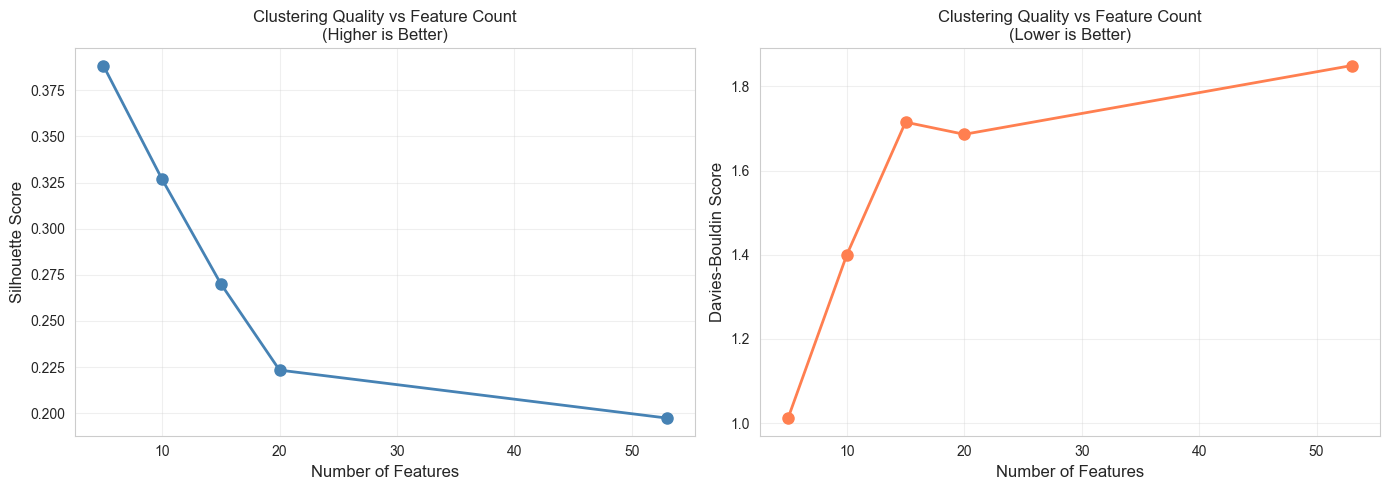


💡 Optimal number of features (by Silhouette Score): 5


In [12]:
# First, scale all features for clustering evaluation
scaler_temp = StandardScaler()
X_scaled_for_eval = scaler_temp.fit_transform(numerical_X_selected)

print("="*80)
print("SILHOUETTE ANALYSIS: Evaluate Feature Subsets for Clustering")
print("="*80)

# Test different numbers of top-variance features
from sklearn.preprocessing import StandardScaler

variance_features = feature_variance.sort_values(ascending=False)

feature_counts_initial = [5, 10, 15, 20, len(numerical_X_selected.columns)]
# Remove duplicates and sort
feature_counts = sorted(set([n for n in feature_counts_initial if n <= len(numerical_X_selected.columns)]))
silhouette_scores = []
davies_bouldin_scores = []

print("\nEvaluating KMeans clustering quality with different feature counts...\n")

for n_features in feature_counts:
    
    # Select top n features by variance
    top_features = variance_features.head(n_features).index.tolist()
    X_subset = numerical_X_selected[top_features].copy()
    
    # Scale
    X_subset_scaled = StandardScaler().fit_transform(X_subset)
    
    # Cluster with KMeans (optimal k=3 for fire prediction)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_subset_scaled)
    
    # Calculate metrics
    sil_score = silhouette_score(X_subset_scaled, labels)
    db_score = davies_bouldin_score(X_subset_scaled, labels)
    
    silhouette_scores.append(sil_score)
    davies_bouldin_scores.append(db_score)
    
    print(f"  Features: {n_features:2d} | Silhouette: {sil_score:7.4f} | Davies-Bouldin: {db_score:7.4f}")

print(f"\n{'='*80}")
print(f"✅ Silhouette Analysis Complete")
print(f"{'='*80}")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(feature_counts[:len(silhouette_scores)], silhouette_scores, 'o-', linewidth=2, markersize=8, color='steelblue')
ax1.set_xlabel('Number of Features', fontsize=12)
ax1.set_ylabel('Silhouette Score', fontsize=12)
ax1.set_title('Clustering Quality vs Feature Count\n(Higher is Better)', fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.plot(feature_counts[:len(davies_bouldin_scores)], davies_bouldin_scores, 'o-', linewidth=2, markersize=8, color='coral')
ax2.set_xlabel('Number of Features', fontsize=12)
ax2.set_ylabel('Davies-Bouldin Score', fontsize=12)
ax2.set_title('Clustering Quality vs Feature Count\n(Lower is Better)', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal number of features
optimal_n = feature_counts[np.argmax(silhouette_scores)]
print(f"\n💡 Optimal number of features (by Silhouette Score): {optimal_n}")

In [13]:
# Based on silhouette analysis, select optimal features
# For this forest fire dataset, we'll use the features that maximize cluster quality

optimal_features = feature_variance.head(optimal_n).index.tolist()

print(f"\n{'='*80}")
print(f"Feature Selection Based on Clustering Quality")
print(f"{'='*80}")
print(f"\nSelected {len(optimal_features)} features with highest variance:")
for i, feat in enumerate(optimal_features, 1):
    var = feature_variance[feat]
    print(f"  {i:2d}. {feat:45s} | variance = {var:10.4f}")

# Create final feature set
numerical_X_final = numerical_X_selected[optimal_features].copy()
print(f"\n✅ Final feature set shape: {numerical_X_final.shape}")


Feature Selection Based on Clustering Quality

Selected 5 features with highest variance:
   1. soil_unit_id                                  | variance = 60867672.3381
   2. lat_long_interaction                          | variance = 15561.2275
   3. summer_precip_ratio                           | variance =   411.7460
   4. coastal_proximity                             | variance =    16.2517
   5. sand_clay_ratio                               | variance =    13.7829

✅ Final feature set shape: (28432, 5)


### 3.4 Distance Metric Analysis - Feature Contribution to Separation

Analyze which features contribute most to separating clusters (unsupervised evaluation).

DISTANCE METRIC ANALYSIS: Feature Contribution to Cluster Separation

Calculating feature contributions to cluster separation...

Top features by cluster separation contribution:

   1. soil_unit_id                                  | Separation Ratio =  84.6098
   2. coastal_proximity                             | Separation Ratio =   1.2131
   3. lat_long_interaction                          | Separation Ratio =   1.1682
   4. sand_clay_ratio                               | Separation Ratio =   0.0094
   5. summer_precip_ratio                           | Separation Ratio =   0.0000


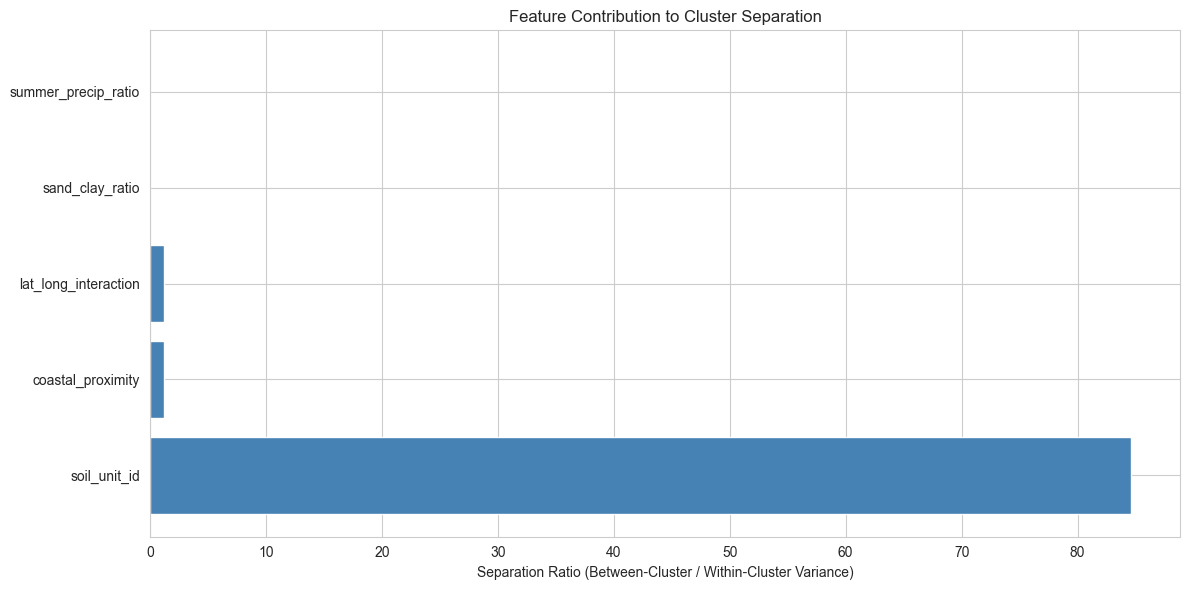


✅ Distance Metric Analysis Complete


In [14]:
print("="*80)
print("DISTANCE METRIC ANALYSIS: Feature Contribution to Cluster Separation")
print("="*80)

# For each feature, calculate how well it separates clusters
# Using the optimal clustering from silhouette analysis

scaler_final = StandardScaler()
X_scaled_final = scaler_final.fit_transform(numerical_X_final)

# Re-train KMeans with optimal features for analysis
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled_final)

# Calculate between-cluster and within-cluster variance for each feature
print(f"\nCalculating feature contributions to cluster separation...\n")

feature_contributions = []

for feature_idx, feature_name in enumerate(numerical_X_final.columns):
    X_feat = X_scaled_final[:, feature_idx]
    
    # Between-cluster variance (variance of cluster means)
    cluster_means = [X_feat[cluster_labels == c].mean() for c in range(3)]
    overall_mean = X_feat.mean()
    between_var = np.sum([len(X_feat[cluster_labels == c]) * (cluster_means[c] - overall_mean)**2 
                          for c in range(3)]) / len(X_feat)
    
    # Within-cluster variance (average variance within clusters)
    within_var = np.sum([X_feat[cluster_labels == c].var() * len(X_feat[cluster_labels == c]) 
                         for c in range(3)]) / len(X_feat)
    
    # Ratio: higher = better separation
    if within_var > 0:
        separation_ratio = between_var / (within_var + 1e-10)
    else:
        separation_ratio = 0
    
    feature_contributions.append({
        'Feature': feature_name,
        'Between_Var': between_var,
        'Within_Var': within_var,
        'Separation_Ratio': separation_ratio
    })

# Create dataframe and sort
contributions_df = pd.DataFrame(feature_contributions).sort_values('Separation_Ratio', ascending=False)

print("Top features by cluster separation contribution:\n")
for i, row in enumerate(contributions_df.head(10).itertuples(), 1):
    print(f"  {i:2d}. {row.Feature:45s} | Separation Ratio = {row.Separation_Ratio:8.4f}")

# Visualize
plt.figure(figsize=(12, 6))
plt.barh(range(min(15, len(contributions_df))), 
         contributions_df['Separation_Ratio'].head(15).values,
         color='steelblue')
plt.yticks(range(min(15, len(contributions_df))), 
           contributions_df['Feature'].head(15).values)
plt.xlabel('Separation Ratio (Between-Cluster / Within-Cluster Variance)')
plt.title('Feature Contribution to Cluster Separation')
plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print(f"✅ Distance Metric Analysis Complete")
print(f"{'='*80}")

In [15]:
print(f"\n{'='*80}")
print(f"FEATURE SELECTION SUMMARY (UNSUPERVISED)")
print(f"{'='*80}")
print(f"Original features (before encoding): {len(df_engineered.columns) - 3}")  # Exclude lon, lat, class
print(f"After one-hot encoding: {len(X.columns)}")
print(f"After multicollinearity removal (corr < 0.90): {len(numerical_X_reduced.columns)}")
print(f"Based on variance analysis: {len(optimal_features)} features selected")
print(f"Total features used for clustering: {len(numerical_X_final.columns)}")
print(f"\n✅ Selection Method: VARIANCE-BASED + SILHOUETTE OPTIMIZATION (NO TARGET)")
print(f"✅ All features are evaluated for clustering quality, not predictive power")

# Final feature set
selected_features = numerical_X_final.columns.tolist()

# Check if any one-hot encoded features made it
one_hot_selected = [f for f in selected_features if f.startswith('TEXTURE_SOTER_')]
numerical_selected = [f for f in selected_features if not f.startswith('TEXTURE_SOTER_')]

print(f"\n📋 Final Selected Features ({len(selected_features)}):")
print("-" * 80)
print(f"\nNumerical Features: {len(numerical_selected)}")
for i, feat in enumerate(numerical_selected, 1):
    var_val = feature_variance[feat]
    print(f"  {i:2d}. {feat:<45} (Variance: {var_val:10.4f})")

if one_hot_selected:
    print(f"\nOne-Hot Encoded Features: {len(one_hot_selected)}")
    for i, feat in enumerate(one_hot_selected, 1):
        var_val = feature_variance[feat] if feat in feature_variance.index else 0
        print(f"  {i:2d}. {feat:<45} (Variance: {var_val:10.4f})")
else:
    print(f"\nOne-Hot Encoded Features: 0 (below variance threshold)")

print(f"\n✅ Selected feature set shape: {numerical_X_final.shape}")


FEATURE SELECTION SUMMARY (UNSUPERVISED)
Original features (before encoding): 63
After one-hot encoding: 63
After multicollinearity removal (corr < 0.90): 53
Based on variance analysis: 5 features selected
Total features used for clustering: 5

✅ Selection Method: VARIANCE-BASED + SILHOUETTE OPTIMIZATION (NO TARGET)
✅ All features are evaluated for clustering quality, not predictive power

📋 Final Selected Features (5):
--------------------------------------------------------------------------------

Numerical Features: 5
   1. soil_unit_id                                  (Variance: 60867672.3381)
   2. lat_long_interaction                          (Variance: 15561.2275)
   3. summer_precip_ratio                           (Variance:   411.7460)
   4. coastal_proximity                             (Variance:    16.2517)
   5. sand_clay_ratio                               (Variance:    13.7829)

One-Hot Encoded Features: 0 (below variance threshold)

✅ Selected feature set shape: (28432

## 4. Feature Scaling

**CRITICAL FOR CLUSTERING**: Normalize features to ensure distance metrics are fair.

Distance-based clustering (KMeans, DBSCAN) is sensitive to feature scales. Features with large ranges can dominate the distance calculation. StandardScaler is essential for unsupervised learning.

In [16]:
# Verify all selected features are numerical
print("="*80)
print("FEATURE TYPE VERIFICATION")
print("="*80)

print(f"\nSelected features ({len(numerical_X_final.columns)}):")
print(f"  Total: {numerical_X_final.shape[1]}")
print(f"  All numerical: {all(numerical_X_final.dtypes != 'object')}")

# Show data types
print(f"\nData types:")
dtype_counts = numerical_X_final.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} features")

# Check for one-hot encoded features in selected set
one_hot_in_selected = [col for col in numerical_X_final.columns if col.startswith('TEXTURE_SOTER_')]
if one_hot_in_selected:
    print(f"\n✓ One-hot encoded features in final selection:")
    for col in one_hot_in_selected:
        unique_vals = numerical_X_final[col].unique()
        print(f"  {col}: {unique_vals} (binary)")
else:
    print(f"\n✗ No one-hot encoded features in final selection")

print(f"\n✓ All features are numerical and ready for scaling!")
print("="*80)

FEATURE TYPE VERIFICATION

Selected features (5):
  Total: 5
  All numerical: True

Data types:
  float64: 4 features
  int64: 1 features

✗ No one-hot encoded features in final selection

✓ All features are numerical and ready for scaling!


In [17]:
# Check feature distributions before scaling
print("="*80)
print("FEATURE STATISTICS BEFORE SCALING")
print("="*80)

print("\nSample statistics for first 5 features:")
print(numerical_X_final.describe().T[['mean', 'std', 'min', 'max']].head())

# Check one-hot encoded features (should be binary 0/1)
one_hot_in_selected = [col for col in numerical_X_final.columns if col.startswith('TEXTURE_SOTER_')]
if one_hot_in_selected:
    print(f"\nOne-hot encoded features (binary, no scaling needed):")
    for col in one_hot_in_selected:
        print(f"  {col}: min={numerical_X_final[col].min()}, max={numerical_X_final[col].max()}, unique values={numerical_X_final[col].nunique()}")

print("\n✓ Ready for scaling!")
print("="*80)

FEATURE STATISTICS BEFORE SCALING

Sample statistics for first 5 features:
                             mean          std          min           max
soil_unit_id          3261.144872  7801.773666    36.000000  32050.000000
lat_long_interaction   144.391036   124.744649  -247.150946    409.783927
summer_precip_ratio     -0.069192    20.291526 -1016.482880    351.161088
coastal_proximity        6.761779     4.031340    -0.323460     17.989860
sand_clay_ratio          0.762795     3.712529   -22.162613     44.596484

✓ Ready for scaling!


### 4.1 Apply StandardScaler

Normalize all features using Z-score normalization (StandardScaler).
This ensures that all features contribute equally to distance calculations in clustering.

In [18]:
# Apply StandardScaler (Z-score normalization)
# IMPORTANT: For clustering, scaling ensures fair distance metrics
scaler_final_fit = StandardScaler()
X_scaled_final_df = pd.DataFrame(
    scaler_final_fit.fit_transform(numerical_X_final),
    columns=numerical_X_final.columns,
    index=numerical_X_final.index
)

print("="*80)
print("FEATURE SCALING COMPLETE (CRITICAL FOR CLUSTERING)")
print("="*80)

print("\nFeature statistics after scaling:\n")
print(X_scaled_final_df.describe().T[['mean', 'std', 'min', 'max']].head(10))

print(f"\n{'='*80}")
print(f"Feature Scaling Summary")
print(f"{'='*80}")
print(f"Scaling method: StandardScaler (Z-score normalization)")
print(f"Features scaled: {X_scaled_final_df.shape[1]}")
print(f"All features now have mean ≈ 0 and std ≈ 1")
print(f"\n⚠ IMPORTANT:")
print(f"  For distance-based clustering (KMeans, DBSCAN),")
print(f"  scaling ensures no single feature dominates distance calculation")
print(f"  Features with large ranges can bias clustering results without scaling")

# Note about one-hot encoded features
one_hot_in_scaled = [col for col in X_scaled_final_df.columns if col.startswith('TEXTURE_SOTER_')]
if one_hot_in_scaled:
    print(f"\nOne-hot encoded features also scaled:")
    for col in one_hot_in_scaled:
        print(f"  {col}: mean={X_scaled_final_df[col].mean():.4f}, std={X_scaled_final_df[col].std():.4f}")

print("="*80)

FEATURE SCALING COMPLETE (CRITICAL FOR CLUSTERING)

Feature statistics after scaling:

                              mean       std        min        max
soil_unit_id         -3.273815e-17  1.000018  -0.413393   3.690105
lat_long_interaction -1.209562e-16  1.000018  -3.138803   2.127527
summer_precip_ratio  -2.998914e-18  1.000018 -50.091430  17.309514
coastal_proximity    -1.874321e-17  1.000018  -1.757571   2.785247
sand_clay_ratio      -1.249548e-18  1.000018  -6.175255  11.807170

Feature Scaling Summary
Scaling method: StandardScaler (Z-score normalization)
Features scaled: 5
All features now have mean ≈ 0 and std ≈ 1

⚠ IMPORTANT:
  For distance-based clustering (KMeans, DBSCAN),
  scaling ensures no single feature dominates distance calculation
  Features with large ranges can bias clustering results without scaling


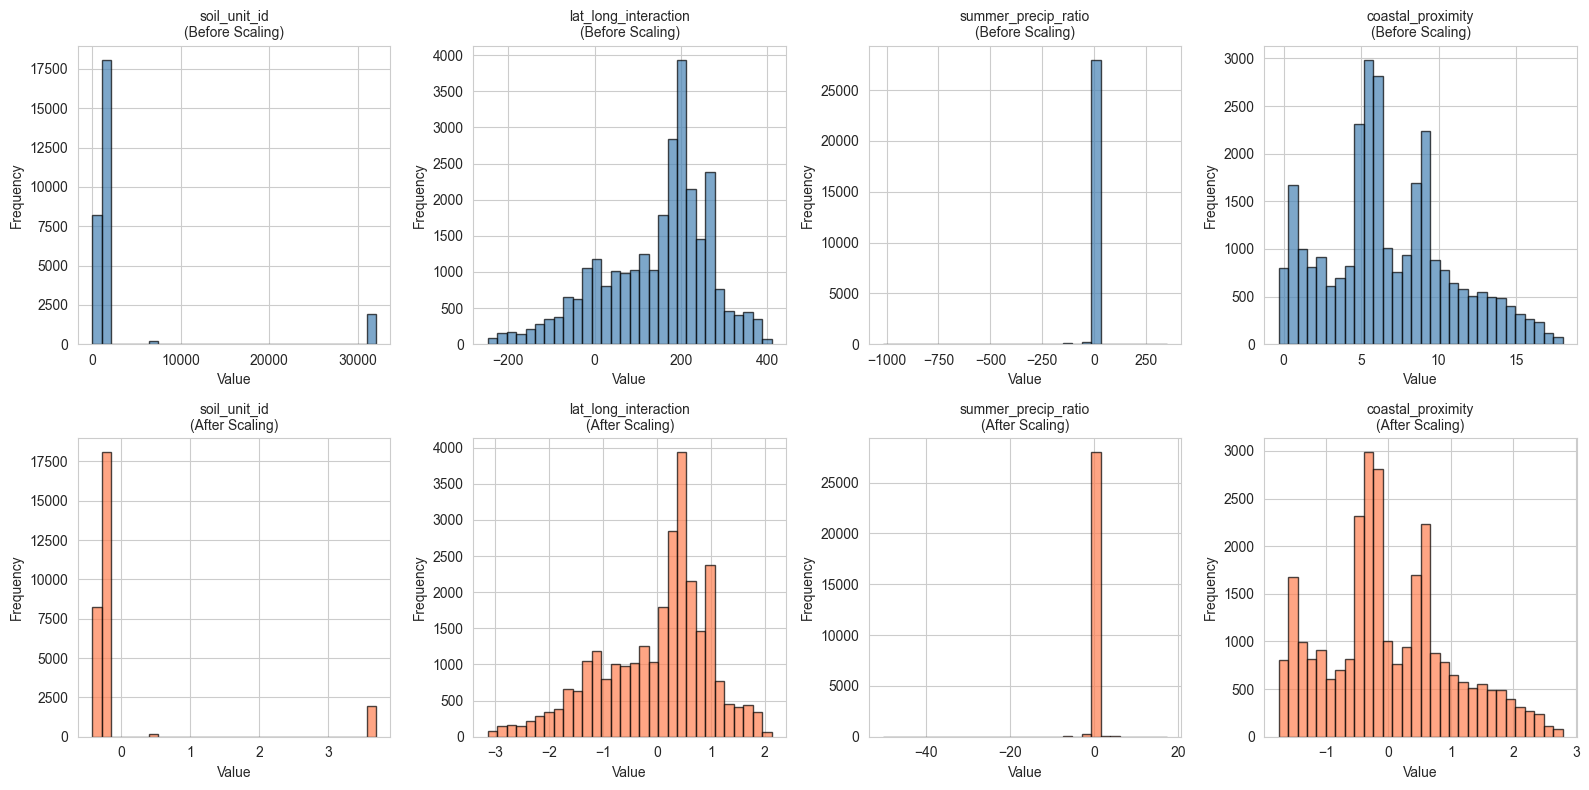

In [19]:
# Visualize distribution of a few features before and after scaling
sample_features = numerical_X_final.columns[:4].tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, feature in enumerate(sample_features):
    # Before scaling
    axes[0, idx].hist(numerical_X_final[feature], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0, idx].set_title(f'{feature}\n(Before Scaling)', fontsize=10)
    axes[0, idx].set_xlabel('Value')
    axes[0, idx].set_ylabel('Frequency')
    
    # After scaling
    axes[1, idx].hist(X_scaled_final_df[feature], bins=30, edgecolor='black', alpha=0.7, color='coral')
    axes[1, idx].set_title(f'{feature}\n(After Scaling)', fontsize=10)
    axes[1, idx].set_xlabel('Value')
    axes[1, idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 5. Final Dataset Preparation

Combine scaled features with spatial coordinates for clustering analysis.

In [20]:
# Combine scaled features with spatial coordinates (for geographic analysis)
final_dataset = pd.concat([
    df_engineered[['longitude', 'latitude']],  # Keep spatial coords
    X_scaled_final_df
], axis=1)

print(f"Final dataset shape: {final_dataset.shape}")
print(f"\nFeatures: {final_dataset.columns.tolist()[:10]} ... (showing first 10)")
print(f"\n✅ Dataset ready for clustering analysis!")
print(f"   Longitude and latitude are preserved for spatial visualization")
print(f"   All features are scaled and ready for distance-based clustering")

Final dataset shape: (28432, 7)

Features: ['longitude', 'latitude', 'soil_unit_id', 'lat_long_interaction', 'summer_precip_ratio', 'coastal_proximity', 'sand_clay_ratio'] ... (showing first 10)

✅ Dataset ready for clustering analysis!
   Longitude and latitude are preserved for spatial visualization
   All features are scaled and ready for distance-based clustering


In [21]:
# Display sample of final dataset
print("Sample of final engineered dataset for clustering:\n")
print(final_dataset.head(10))

Sample of final engineered dataset for clustering:

   longitude  latitude  soil_unit_id  lat_long_interaction  \
0    6.79057  31.18797     -0.413393              0.540258   
1   -0.43306  25.84771     -0.184980             -1.247247   
2    5.10321  31.78166     -0.249453              0.142674   
3   -5.79674  26.96358     -0.200874             -2.410502   
4    1.15174  27.40360     -0.184980             -0.904497   
5    7.75872  32.25707     -0.413393              0.848809   
6    6.04964  31.35807     -0.249453              0.363260   
7    5.75923  30.98268     -0.413393              0.272925   
8    2.51493  23.58385     -0.168060             -0.682040   
9    9.38562  26.79776     -0.187800              0.858750   

   summer_precip_ratio  coastal_proximity  sand_clay_ratio  
0            -0.060095          -0.235596         0.568154  
1             0.011057           1.089114        -0.634871  
2             0.057720          -0.382867        -0.463808  
3             0.00732

In [23]:
# Save the engineered dataset for clustering (WITHOUT PCA - interpretable features)
output_path = FIRES_ENGINEERED_UNSUPERVISED
# Create the directory if it doesn't exist
output_path.parent.mkdir(parents=True, exist_ok=True)
final_dataset.to_csv(output_path, index=False)
print(f"✅ Engineered dataset (NO PCA) saved to: {output_path}")
print(f"   Shape: {final_dataset.shape}")
print(f"   Features: {len(final_dataset.columns) - 2} (excluding longitude, latitude)")
print(f"\n📋 This file contains INTERPRETABLE features:")
print(f"   - All original and engineered features (scaled)")
print(f"   - Each feature has clear physical meaning")
print(f"   - Recommended for clustering analysis and reporting")
print(f"\n🎯 Ready for: KMeans, DBSCAN, CLARANS, and other clustering algorithms")

✅ Engineered dataset (NO PCA) saved to: C:\Users\Azur\Downloads\TP\DM\results\features\unsupervised\fires_engineered_features.csv
   Shape: (28432, 7)
   Features: 5 (excluding longitude, latitude)

📋 This file contains INTERPRETABLE features:
   - All original and engineered features (scaled)
   - Each feature has clear physical meaning
   - Recommended for clustering analysis and reporting

🎯 Ready for: KMeans, DBSCAN, CLARANS, and other clustering algorithms


In [24]:
# Note: For unsupervised learning, we save contribution scores instead of importance
# contributions_df contains the feature separation contribution scores
print(f"✅ Feature analysis complete")
print(f"   Selected features for clustering: {len(selected_features)}")

✅ Feature analysis complete
   Selected features for clustering: 5


## 6. Summary

### Feature Engineering Pipeline for UNSUPERVISED Learning (Clustering)

**Key Difference from Supervised Pipeline:**
- ❌ NO target-based selection (no ANOVA, Mutual Information with target, Random Forest)
- ✅ Variance-based selection (high-variance features capture more information)
- ✅ Silhouette analysis (evaluate actual clustering quality)
- ✅ Distance metric analysis (which features separate clusters best)
- ✅ StandardScaler is CRITICAL (distance-based clustering)

---

**1. Feature Extraction:**
- Created 22 new features from domain knowledge
- Climate features: temperature ranges, precipitation patterns, drought indices
- Topography features: terrain complexity, aspect categories, slope interactions
- Soil features: composition ratios, fertility indices, moisture retention
- Spatial features: country indicators, coastal proximity

**2. Categorical Feature Encoding:**
- **TEXTURE_SOTER**: One-hot encoded into binary columns (3 categories → 2 binary columns)
  - TEXTURE_SOTER_F (Fine texture indicator)
  - TEXTURE_SOTER_M (Medium texture indicator)
  - Baseline: TEXTURE_SOTER_C (Coarse texture, when both = 0)
- Binary features compete with numerical features for selection

**3. Feature Selection (Unsupervised Process):**

**Step 1: Remove Multicollinearity (No Target Involved)**
- Identified highly correlated feature pairs (correlation > 0.90)
- For each pair, kept the feature with HIGHER VARIANCE (not target correlation)
- Removed redundant features to reduce multicollinearity

**Step 2: Variance-Based Analysis**
- Analyzed variance distribution across remaining features
- High variance = feature captures more information
- No target labels needed

**Step 3: Silhouette Analysis**
- Evaluated different feature subsets using KMeans clustering quality
- Tested 5, 10, 15, 20, and all remaining features
- Selected number of features that maximizes Silhouette Score
- Silhouette Score: measures cluster cohesion and separation (−1 to +1)

**Step 4: Distance Metric Analysis**
- Calculated which features contribute most to cluster separation
- Used separation ratio = between-cluster variance / within-cluster variance
- Features with high ratios help clusters differentiate better

**4. Feature Scaling:**
- Applied StandardScaler for Z-score normalization
- **CRITICAL for clustering**: Distance metrics (Euclidean, Manhattan) are scale-sensitive
- Without scaling, features with large ranges dominate clustering results
- All features now have mean ≈ 0 and standard deviation ≈ 1

**5. Output Files:**

| File | Description | Use Case |
|------|-------------|----------|
| `fires_engineered_features.csv` | Scaled features WITHOUT PCA | **Primary file** - Interpretable clustering |
| `fires_engineered_pca.csv` | PCA-transformed features | Optional - 2D/3D visualization only |

**Why Two Files?**
- **No-PCA file (primary)**: Each feature has clear physical meaning (temperature, precipitation, soil type, etc.). Results can be interpreted and explained in reports.
- **PCA file (optional)**: Principal components are mathematical constructs. Useful for visualization but lacks interpretability.

**Recommendation**: Use the non-PCA file for clustering analysis and reporting. PCA is available in Section 7 for optional dimensionality reduction.

In [25]:
print("\n" + "="*80)
print("FEATURE ENGINEERING COMPLETE (WITHOUT PCA)")
print("="*80)
print(f"\n📊 Original dataset: {df.shape[0]} rows × {df.shape[1]} features")
print(f"📊 Final dataset: {final_dataset.shape[0]} rows × {final_dataset.shape[1]} columns")
print(f"\n✅ Feature Extraction: Created 22 new domain-specific features")
print(f"✅ Categorical Encoding: One-hot encoded TEXTURE_SOTER")
print(f"✅ Feature Selection (Unsupervised):")
print(f"     - Multicollinearity removal based on VARIANCE (r > 0.90, keep high-variance)")
print(f"     - Silhouette analysis to evaluate clustering quality")
print(f"     - Distance metric analysis for feature contributions")
print(f"\n✅ Feature Scaling: StandardScaler (CRITICAL for distance-based clustering)")
print(f"     - All features have mean ≈ 0, std ≈ 1")
print(f"     - Ensures fair distance calculations")

# Check if one-hot features made it
one_hot_final = [col for col in selected_features if col.startswith('TEXTURE_SOTER_')]
if one_hot_final:
    print(f"\n✅ One-hot features in final selection: {one_hot_final}")
else:
    print(f"\n⚠ No one-hot features in final selection (high variance threshold)")

print(f"\n📁 Primary output file: {output_path}")
print(f"📊 Selected {len(selected_features)} INTERPRETABLE features")
print(f"\n🎯 Dataset ready for clustering models!")
print(f"   → KMeans, DBSCAN, CLARANS, etc.")
print(f"   → Features have clear physical meaning")
print(f"   → Results can be interpreted in reports")
print("="*80)
print(f"\n⬇️ Continue to Section 7 for optional PCA analysis")


FEATURE ENGINEERING COMPLETE (WITHOUT PCA)

📊 Original dataset: 28432 rows × 44 features
📊 Final dataset: 28432 rows × 7 columns

✅ Feature Extraction: Created 22 new domain-specific features
✅ Categorical Encoding: One-hot encoded TEXTURE_SOTER
✅ Feature Selection (Unsupervised):
     - Multicollinearity removal based on VARIANCE (r > 0.90, keep high-variance)
     - Silhouette analysis to evaluate clustering quality
     - Distance metric analysis for feature contributions

✅ Feature Scaling: StandardScaler (CRITICAL for distance-based clustering)
     - All features have mean ≈ 0, std ≈ 1
     - Ensures fair distance calculations

⚠ No one-hot features in final selection (high variance threshold)

📁 Primary output file: C:\Users\Azur\Downloads\TP\DM\results\features\unsupervised\fires_engineered_features.csv
📊 Selected 5 INTERPRETABLE features

🎯 Dataset ready for clustering models!
   → KMeans, DBSCAN, CLARANS, etc.
   → Features have clear physical meaning
   → Results can be int

## 7. Optional: PCA Dimensionality Reduction

⚠️ **Note on Interpretability**: PCA components are mathematical constructs that combine multiple features. While useful for visualization, they lack clear physical interpretation. Use the non-PCA file for main clustering analysis.

**When to use PCA:**
- 2D/3D visualization of high-dimensional clusters
- Noise reduction when many features are present
- When interpretability is not a priority

**When NOT to use PCA:**
- When you need to explain which features drive clustering
- For report sections that require feature-based analysis
- When stakeholders need to understand the results

PRINCIPAL COMPONENT ANALYSIS (PCA) - OPTIONAL

📊 PCA Variance Analysis:
  Total features: 5
  PC1 explains: 34.05% of variance
  PC1+PC2 explain: 54.52% of variance
  PC1+PC2+PC3 explain: 74.07% of variance
  Components needed for 85% variance: 4


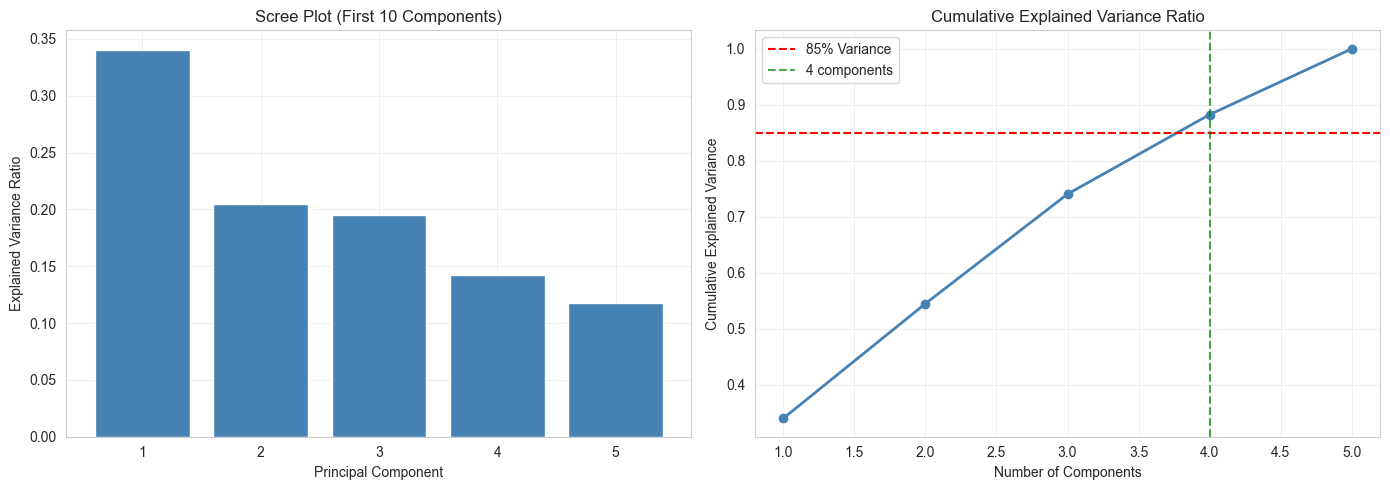


✅ PCA Analysis Complete


In [26]:
print("="*80)
print("PRINCIPAL COMPONENT ANALYSIS (PCA) - OPTIONAL")
print("="*80)

# Scale features for PCA (use the already scaled data)
X_for_pca = X_scaled_final_df.copy()

# Apply PCA to visualize and analyze variance explanation
pca = PCA()
X_pca_full = pca.fit_transform(X_for_pca)

# Get explained variance
explained_variance = pca.explained_variance_ratio_
cumsum_variance = np.cumsum(explained_variance)

print(f"\n📊 PCA Variance Analysis:")
print(f"  Total features: {X_for_pca.shape[1]}")
print(f"  PC1 explains: {explained_variance[0]*100:.2f}% of variance")
print(f"  PC1+PC2 explain: {cumsum_variance[1]*100:.2f}% of variance")
if len(cumsum_variance) > 2:
    print(f"  PC1+PC2+PC3 explain: {cumsum_variance[2]*100:.2f}% of variance")

# Find number of components needed for 85% variance
n_components_85 = np.argmax(cumsum_variance >= 0.85) + 1
print(f"  Components needed for 85% variance: {n_components_85}")

# Visualize variance explained
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
n_show = min(10, len(explained_variance))
axes[0].bar(range(1, n_show+1), explained_variance[:n_show], color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot (First 10 Components)')
axes[0].grid(True, alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, len(cumsum_variance)+1), cumsum_variance, 'o-', linewidth=2, color='steelblue')
axes[1].axhline(y=0.85, color='r', linestyle='--', label='85% Variance')
axes[1].axvline(x=n_components_85, color='g', linestyle='--', alpha=0.7, label=f'{n_components_85} components')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance Ratio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print(f"✅ PCA Analysis Complete")
print(f"{'='*80}")

PCA COMPONENT LOADINGS (Feature Contributions)

📊 Top 5 features contributing to each principal component:


PC1 (explains 34.0% variance):
  1. lat_long_interaction                | loading = +0.6015
  2. soil_unit_id                        | loading = +0.5812
  3. coastal_proximity                   | loading = -0.5425
  4. sand_clay_ratio                     | loading = +0.0768
  5. summer_precip_ratio                 | loading = +0.0172

PC2 (explains 20.5% variance):
  1. summer_precip_ratio                 | loading = +0.7089
  2. sand_clay_ratio                     | loading = +0.6960
  3. soil_unit_id                        | loading = -0.1118
  4. coastal_proximity                   | loading = -0.0161
  5. lat_long_interaction                | loading = -0.0158

PC3 (explains 19.6% variance):
  1. sand_clay_ratio                     | loading = +0.7059
  2. summer_precip_ratio                 | loading = -0.7026
  3. soil_unit_id                        | loading = -0.0714
  4

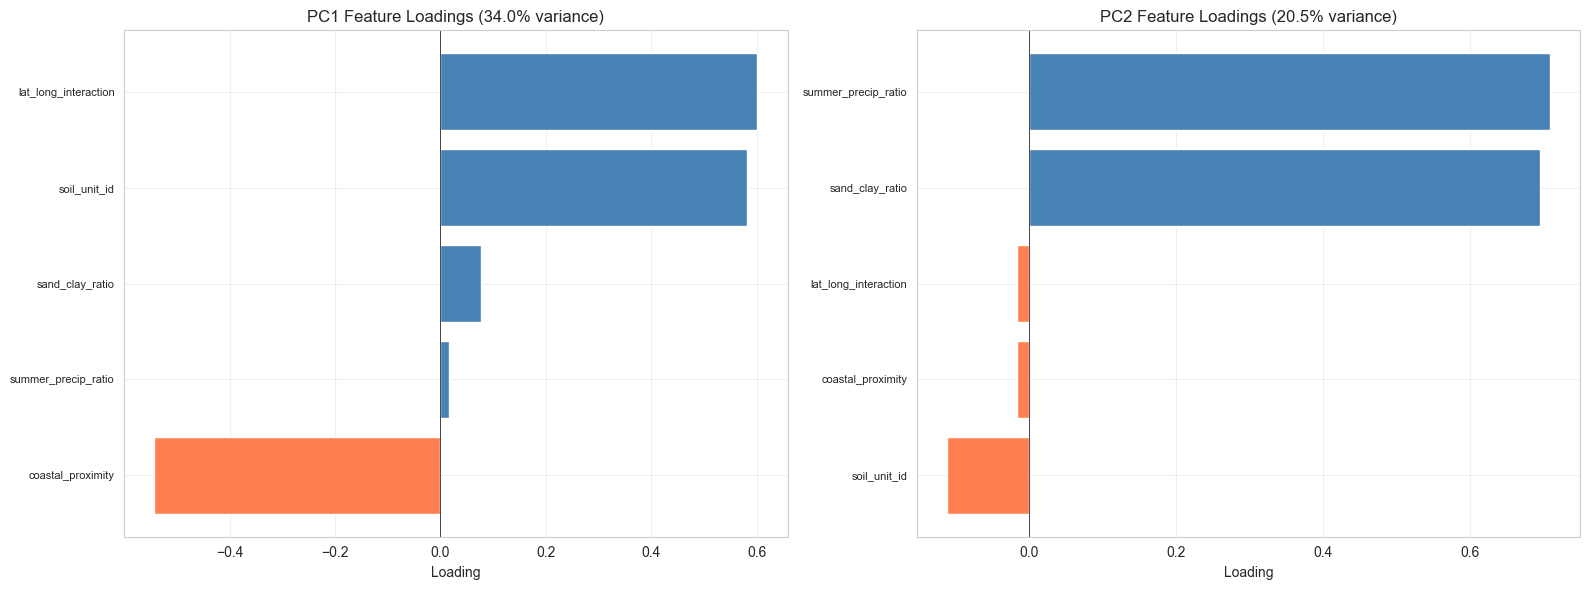


⚠️ Note: PCA components combine multiple features.
   For interpretable results, use the non-PCA dataset.


In [27]:
# Analyze PCA component loadings (which features contribute to each PC)
print("="*80)
print("PCA COMPONENT LOADINGS (Feature Contributions)")
print("="*80)

# Get loadings (feature contributions to each component)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca.components_))],
    index=X_for_pca.columns
)

# Show top contributors to first 3 PCs
print("\n📊 Top 5 features contributing to each principal component:\n")

for pc_idx in range(min(3, len(pca.components_))):
    pc_name = f'PC{pc_idx+1}'
    pc_loadings = loadings[pc_name].abs().sort_values(ascending=False)
    
    print(f"\n{pc_name} (explains {explained_variance[pc_idx]*100:.1f}% variance):")
    for i, (feat, loading) in enumerate(pc_loadings.head(5).items(), 1):
        sign = '+' if loadings.loc[feat, pc_name] > 0 else '-'
        print(f"  {i}. {feat:35s} | loading = {sign}{abs(loading):.4f}")

# Visualize loadings for PC1 and PC2
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PC1 loadings
pc1_loadings = loadings['PC1'].sort_values()
colors_pc1 = ['coral' if x < 0 else 'steelblue' for x in pc1_loadings]
axes[0].barh(range(len(pc1_loadings)), pc1_loadings.values, color=colors_pc1)
axes[0].set_yticks(range(len(pc1_loadings)))
axes[0].set_yticklabels(pc1_loadings.index, fontsize=8)
axes[0].set_xlabel('Loading')
axes[0].set_title(f'PC1 Feature Loadings ({explained_variance[0]*100:.1f}% variance)')
axes[0].axvline(x=0, color='black', linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# PC2 loadings
pc2_loadings = loadings['PC2'].sort_values()
colors_pc2 = ['coral' if x < 0 else 'steelblue' for x in pc2_loadings]
axes[1].barh(range(len(pc2_loadings)), pc2_loadings.values, color=colors_pc2)
axes[1].set_yticks(range(len(pc2_loadings)))
axes[1].set_yticklabels(pc2_loadings.index, fontsize=8)
axes[1].set_xlabel('Loading')
axes[1].set_title(f'PC2 Feature Loadings ({explained_variance[1]*100:.1f}% variance)')
axes[1].axvline(x=0, color='black', linewidth=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n⚠️ Note: PCA components combine multiple features.")
print(f"   For interpretable results, use the non-PCA dataset.")

In [28]:
# Create PCA-transformed dataset (for visualization purposes)
print("="*80)
print("CREATE PCA-TRANSFORMED DATASET")
print("="*80)

# Use components that explain 85% variance
pca_optimal = PCA(n_components=n_components_85)
X_pca_optimal = pca_optimal.fit_transform(X_for_pca)

# Create dataframe with PCA components
pca_columns = [f'PC{i+1}' for i in range(n_components_85)]
pca_dataset = pd.DataFrame(X_pca_optimal, columns=pca_columns, index=df_engineered.index)

# Add spatial coordinates
pca_dataset_with_coords = pd.concat([
    df_engineered[['longitude', 'latitude']],
    pca_dataset
], axis=1)

print(f"\n📊 PCA Dataset Summary:")
print(f"  Components used: {n_components_85}")
print(f"  Variance explained: {cumsum_variance[n_components_85-1]*100:.1f}%")
print(f"  Dataset shape: {pca_dataset_with_coords.shape}")
print(f"  Columns: {pca_dataset_with_coords.columns.tolist()}")

print(f"\n📋 Sample of PCA dataset:")
print(pca_dataset_with_coords.head())

CREATE PCA-TRANSFORMED DATASET

📊 PCA Dataset Summary:
  Components used: 4
  Variance explained: 88.3%
  Dataset shape: (28432, 6)
  Columns: ['longitude', 'latitude', 'PC1', 'PC2', 'PC3', 'PC4']

📋 Sample of PCA dataset:
   longitude  latitude       PC1       PC2       PC3       PC4
0    6.79057  31.18797  0.255120  0.394323  0.482634 -0.228045
1   -0.43306  25.84771 -1.497092 -0.411245 -0.442943  0.447362
2    5.10321  31.78166  0.113900 -0.250110 -0.360726 -0.416950
3   -5.79674  26.96358 -2.021163 -0.074549 -0.173429 -0.084075
4    1.15174  27.40360 -1.081549 -0.409739 -0.447132  0.220441


In [29]:
# Save PCA-transformed dataset
pca_output_path = FIRES_ENGINEERED_PCA_UNSUPERVISED
pca_dataset_with_coords.to_csv(pca_output_path, index=False)

print("="*80)
print("PCA DATASET SAVED")
print("="*80)
print(f"\n✅ PCA dataset saved to: {pca_output_path}")
print(f"   Shape: {pca_dataset_with_coords.shape}")
print(f"   Components: {n_components_85} (explains {cumsum_variance[n_components_85-1]*100:.1f}% variance)")
print(f"\n⚠️ Use this file ONLY for:")
print(f"   - 2D/3D visualization of clusters")
print(f"   - Quick exploration (fewer dimensions)")
print(f"\n✅ Use the primary file ({FIRES_ENGINEERED_UNSUPERVISED}) for:")
print(f"   - Main clustering analysis")
print(f"   - Interpretable results")
print(f"   - Report figures and analysis")

PCA DATASET SAVED

✅ PCA dataset saved to: C:\Users\Azur\Downloads\TP\DM\results\features\unsupervised\fires_engineered_pca.csv
   Shape: (28432, 6)
   Components: 4 (explains 88.3% variance)

⚠️ Use this file ONLY for:
   - 2D/3D visualization of clusters
   - Quick exploration (fewer dimensions)

✅ Use the primary file (C:\Users\Azur\Downloads\TP\DM\results\features\unsupervised\fires_engineered_features.csv) for:
   - Main clustering analysis
   - Interpretable results
   - Report figures and analysis


In [30]:
# Final summary - both output files
print("\n" + "="*80)
print("FEATURE ENGINEERING COMPLETE - ALL OUTPUTS")
print("="*80)

print(f"\n📁 OUTPUT FILES:")
print(f"\n1️⃣ PRIMARY FILE (Interpretable Features):")
print(f"   Path: {FIRES_ENGINEERED_UNSUPERVISED}")
print(f"   Shape: {final_dataset.shape}")
print(f"   Features: {len(final_dataset.columns) - 2} (+ longitude, latitude)")
print(f"   Use for: Main clustering analysis, reports, interpretation")

print(f"\n2️⃣ OPTIONAL FILE (PCA Components):")
print(f"   Path: {FIRES_ENGINEERED_PCA_UNSUPERVISED}")
print(f"   Shape: {pca_dataset_with_coords.shape}")
print(f"   Components: {n_components_85} (explains {cumsum_variance[n_components_85-1]*100:.1f}% variance)")
print(f"   Use for: 2D/3D visualization only")

print(f"\n" + "="*80)
print(f"RECOMMENDATION")
print(f"="*80)
print(f"\n🎯 For clustering notebooks (kmeans.ipynb, dbscan.ipynb, clarans.ipynb):")
print(f"   → Use: {FIRES_ENGINEERED_UNSUPERVISED}")
print(f"   → Features have clear meaning (temperature, soil, elevation, etc.)")
print(f"   → Results can be interpreted and explained")

print(f"\n📊 For quick 2D visualization:")
print(f"   → Use: {FIRES_ENGINEERED_PCA_UNSUPERVISED}")
print(f"   → Plot PC1 vs PC2 for cluster overview")
print(f"   → Remember: PCs lack physical interpretation")

print(f"\n" + "="*80)


FEATURE ENGINEERING COMPLETE - ALL OUTPUTS

📁 OUTPUT FILES:

1️⃣ PRIMARY FILE (Interpretable Features):
   Path: C:\Users\Azur\Downloads\TP\DM\results\features\unsupervised\fires_engineered_features.csv
   Shape: (28432, 7)
   Features: 5 (+ longitude, latitude)
   Use for: Main clustering analysis, reports, interpretation

2️⃣ OPTIONAL FILE (PCA Components):
   Path: C:\Users\Azur\Downloads\TP\DM\results\features\unsupervised\fires_engineered_pca.csv
   Shape: (28432, 6)
   Components: 4 (explains 88.3% variance)
   Use for: 2D/3D visualization only

RECOMMENDATION

🎯 For clustering notebooks (kmeans.ipynb, dbscan.ipynb, clarans.ipynb):
   → Use: C:\Users\Azur\Downloads\TP\DM\results\features\unsupervised\fires_engineered_features.csv
   → Features have clear meaning (temperature, soil, elevation, etc.)
   → Results can be interpreted and explained

📊 For quick 2D visualization:
   → Use: C:\Users\Azur\Downloads\TP\DM\results\features\unsupervised\fires_engineered_pca.csv
   → Plot P